In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu

np.random.seed(42)
import random
random.seed(42)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import os
os.environ["SCIPY_ARRAY_API"] = "1"
from imblearn.over_sampling import RandomOverSampler

torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

torch.cuda.is_available()


True

In [3]:
file_name = 'merged_EAE_CD4_logit_embs'
features = pd.read_csv(f'{file_name}.csv')
features.head(5)


,Unnamed: 0,feature_gex1,feature_gex2,feature_gex3,feature_gex4,feature_gex5,feature_gex6,feature_gex7,feature_gex8,feature_gex9,...,feature_tcr1313,feature_tcr1314,feature_tcr1315,feature_tcr1316,feature_tcr1317,lr_score,label_tissue,label_cell_type,label_state,label_set
0,ACCAGAGAGCCAGAGA-1_0516_CNS,0.625604,1.101336,-0.872533,0.362678,0.348406,1.691799,-1.513119,1.556052,-0.220529,...,0.050723,-0.104547,2.176592e-13,-0.358447,-1.058772,-0.237625,CNS,CD4,Activation,train
1,ATGAGGAGTCTATTCG-1_0516_CNS,-1.633328,-0.016522,1.186384,-0.566553,-0.412338,1.130019,0.333264,0.921487,1.483764,...,0.050723,-0.104547,2.176592e-13,0.607462,-0.088085,-0.309389,CNS,NaN,Activation,train
2,CACTACGCACCACACA-1_0516_CNS,-0.022191,1.078571,-0.943021,-0.652273,1.530086,0.987665,-0.131203,1.342826,-0.098099,...,0.050723,-0.104547,2.176592e-13,0.607462,0.882603,0.041931,CNS,Treg,Activation,train
3,CAGCATATCCCGTAAA-1_0516_CNS,0.963593,1.206184,-0.711800,0.146631,0.559764,1.607911,-1.158318,1.712503,-0.349028,...,0.050723,-0.104547,2.176592e-13,-0.358447,-1.058772,-0.237625,CNS,CD4,Activation,train
4,CCCAACACAGCGTATT-1_0516_CNS,2.107041,-0.101425,-0.238915,0.194247,-0.041171,0.060662,0.256297,0.088335,2.699889,...,0.050723,-0.104547,2.176592e-13,-0.358447,-0.088085,-0.119925,CNS,NaN,Activation,train


In [27]:
all_tcr_features = True
topN_weights = 50 # Number of top TCR features to select based on weights


In [28]:
features['label_tissue'] = features['label_tissue'].apply(lambda x: 'CNS' if x == 'CNS' else 'Not CNS')
features['label_tissue'].value_counts()


label_tissue
CNS        13676
Not CNS    10094
Name: count, dtype: int64

In [29]:
features['label_state'].value_counts()


label_state
Activation    3497
Exhaust       2690
IFN_stim      1185
Mem_Naive      649
Name: count, dtype: int64

In [30]:
required_columns = {"label_tissue", "label_set"}
missing_required = required_columns - set(features.columns)
if missing_required:
    raise ValueError(f"Dataset is missing required columns: {missing_required}")

clean_df = features.dropna(subset=required_columns).copy()
dropped_rows = len(features) - len(clean_df)
if dropped_rows > 0:
    print(f"Dropped {dropped_rows} rows with missing 'label_tissue' or 'label_set'.")

label_series = clean_df['label_tissue']
label_encoder = {label: idx for idx, label in enumerate(sorted(label_series.unique()))}
num_classes = len(label_encoder)
if num_classes != 2:
    raise ValueError(f"Expected exactly two classes for binary classification, found {num_classes}.")

labels = label_series.map(label_encoder).astype(np.float32).values

set_series = clean_df['label_set'].str.lower()
allowed_sets = {"train", "test"}
if not set(set_series.unique()).issubset(allowed_sets):
    raise ValueError("'label_set' must contain only 'train' and 'test' values.")

train_mask = set_series == 'train'
test_mask = set_series == 'test'
if train_mask.sum() == 0 or test_mask.sum() == 0:
    raise ValueError("Both train and test splits must contain at least one sample.")

train_indices = np.where(train_mask)[0]
test_indices = np.where(test_mask)[0]

feature_sets = {
    "feature_gex": [col for col in clean_df.columns if col.startswith('feature_gex')],
}

# feature_sets["feature_gex_tcr"] = sorted({*feature_sets["feature_gex"], *feature_sets["feature_tcr"]})


In [31]:
from typing import Any

if all_tcr_features:
    tcr_prefix = "feature_tcr"
    all_tcr_columns = [col for col in clean_df.columns if col.startswith(tcr_prefix)]
    
    # Load weights and select top N features
    weights_path = f"./data/EAE/CCA/merged_EAE_CD4_logit_weights.npz"
    try:
        weights = np.load(weights_path)
        tcr_weights = weights["tcr"]  # Shape: (n_features, n_components)
        
        # Use absolute values and sum across components (or use first component)
        # Sum absolute values across all components to get overall importance
        feature_importance = np.abs(tcr_weights).sum(axis=1) if tcr_weights.ndim > 1 else np.abs(tcr_weights)
        
        # Get indices of top N features
        top_indices = np.argsort(feature_importance)[-topN_weights:][::-1]  # Sort descending
        
        # Map indices to column names (assuming columns are in order: feature_tcr1, feature_tcr2, ...)
        # Extract numeric part from column names to match with indices
        tcr_column_numbers = []
        for col in all_tcr_columns:
            # Extract number from "feature_tcr123" -> 123
            try:
                num = int(col.replace(tcr_prefix, ""))
                tcr_column_numbers.append((num, col))
            except ValueError:
                continue
        
        # Sort by number and select top N
        tcr_column_numbers.sort(key=lambda x: x[0])
        if len(tcr_column_numbers) != len(feature_importance):
            print(f"Warning: Number of TCR columns ({len(tcr_column_numbers)}) doesn't match weights shape ({len(feature_importance)}). Using all columns.")
            tcr_columns = all_tcr_columns
        else:
            # Select top N columns based on weights
            selected_indices = top_indices[:topN_weights]
            tcr_columns = [tcr_column_numbers[i][1] for i in selected_indices if i < len(tcr_column_numbers)]
            print(f"Selected top {len(tcr_columns)} TCR features based on weights (topN_weights={topN_weights})")
    except FileNotFoundError:
        print(f"Warning: Weights file not found at {weights_path}. Using all TCR features.")
        tcr_columns = all_tcr_columns
    except Exception as e:
        print(f"Warning: Error loading weights: {e}. Using all TCR features.")
        tcr_columns = all_tcr_columns
        
else:
    # Use 'lr_score' column when all_tcr_features is False
    if 'lr_score' not in clean_df.columns:
        raise ValueError("'lr_score' column not found in the dataset.")
    tcr_columns = ['lr_score']
    tcr_prefix = "lr_score"

if not tcr_columns:
    raise ValueError(f"No columns found with prefix '{tcr_prefix}'.")

feature_sets["feature_tcr"] = tcr_columns
feature_sets["feature_gex_tcr"] = sorted({*feature_sets["feature_gex"], *feature_sets["feature_tcr"]})

print(f"TCR feature prefix: {tcr_prefix} (all_tcr_features={all_tcr_features})")

for key, cols in feature_sets.items():
    print(f"{key}: {len(cols)} columns")


TCR feature prefix: feature_tcr (all_tcr_features=True)
feature_gex: 50 columns
feature_tcr: 1317 columns
feature_gex_tcr: 1367 columns


In [39]:
len(tcr_columns)

1317

In [32]:
from IPython.display import display

if 'label_encoded' not in clean_df.columns:
    clean_df['label_encoded'] = clean_df['label_tissue'].map(label_encoder).astype(np.float32)

cell_type_categories = sorted(clean_df['label_cell_type'].dropna().unique())
state_categories = sorted(clean_df['label_state'].dropna().unique())


class BinaryClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def build_loaders(df, selected_columns, batch_size_train=64, batch_size_test=128):
    if len(selected_columns) == 0:
        raise ValueError("Selected feature list is empty.")
    if df.empty:
        raise ValueError("No rows available after filtering.")

    set_series = df['label_set'].str.lower()
    train_mask = set_series == 'train'
    test_mask = set_series == 'test'

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        raise ValueError("Both train and test splits must contain at least one sample.")

    y = df['label_encoded'].astype(np.float32).values
    y_train = y[train_mask]
    y_test = y[test_mask]

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        raise ValueError("Train and test splits must each contain both classes.")

    X = df[selected_columns].astype(np.float32).values
    X_train = np.ascontiguousarray(X[train_mask])
    X_test = np.ascontiguousarray(X[test_mask])

    y_train = np.ascontiguousarray(y_train)
    y_test = np.ascontiguousarray(y_test)

    ros = RandomOverSampler(random_state=42)
    X_train, y_train = ros.fit_resample(X_train, y_train)

    X_train = np.ascontiguousarray(X_train, dtype=np.float32)
    y_train = np.ascontiguousarray(y_train.astype(np.float32))

    train_dataset = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train),
    )
    test_dataset = TensorDataset(
        torch.from_numpy(X_test),
        torch.from_numpy(y_test),
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size_test, shuffle=False)

    return train_loader, test_loader, X.shape[1]


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    count = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.sigmoid(logits) > 0.5
            correct += (preds.int() == yb.int()).sum().item()
            count += xb.size(0)
    avg_loss = total_loss / max(count, 1)
    accuracy = correct / max(count, 1)
    return avg_loss, accuracy


def train_single_run(run_label, df, selected_columns, device, num_epochs, learning_rate):
    try:
        train_loader, test_loader, input_dim = build_loaders(df, selected_columns)
    except ValueError as exc:
        print(f"Skipping {run_label}: {exc}")
        return None

    model = BinaryClassifier(input_dim=input_dim, hidden_dim=128).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    log_epochs = {1, num_epochs}
    if num_epochs >= 10:
        log_epochs.update(range(10, num_epochs + 1, 10))

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

        train_loss = running_loss / max(len(train_loader.dataset), 1)
        test_loss, test_acc = evaluate(model, test_loader, device)

        if epoch in log_epochs:
            print(
                f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.3f}"
            )

    final_train_loss, _ = evaluate(model, train_loader, device)
    final_test_loss, final_test_acc = evaluate(model, test_loader, device)

    return {
        "train_loss": final_train_loss,
        "test_loss": final_test_loss,
        "test_acc": round(final_test_acc, 3),
    }


def run_scope(scope_name, df, feature_sets, device, num_epochs, learning_rate):
    scope_results = []
    print(f"\n=== Scope: {scope_name} | samples={len(df)} ===")
    for feature_name, selected_columns in feature_sets.items():
        run_label = f"{scope_name} | {feature_name}"
        print(f"\n--- Training on {feature_name} ({len(selected_columns)} features) ---")
        result = train_single_run(run_label, df, selected_columns, device, num_epochs, learning_rate)
        if result is None:
            continue
        cns_ratio = df['label_tissue'].eq('CNS').mean() if len(df) > 0 else np.nan
        result.update({
            "scope": scope_name,
            "feature_set": feature_name,
            "num_features": len(selected_columns),
            "samples": len(df),
            "cns_pct_unbalanced": round(cns_ratio * 100, 3) if not np.isnan(cns_ratio) else np.nan,
        })
        scope_results.append(result)
    return scope_results


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.BCEWithLogitsLoss()
num_epochs = 10
learning_rate = 1e-3

all_results = []

# Overall dataset
all_results.extend(run_scope("all_samples", clean_df, feature_sets, device, num_epochs, learning_rate))

# Subsets by label_cell_type
for cell_type in cell_type_categories:
    subset_df = clean_df[clean_df['label_cell_type'] == cell_type]
    scope_name = f"label_cell_type={cell_type}"
    all_results.extend(run_scope(scope_name, subset_df, feature_sets, device, num_epochs, learning_rate))

# Subsets by label_state
for state in state_categories:
    subset_df = clean_df[clean_df['label_state'] == state]
    scope_name = f"label_state={state}"
    all_results.extend(run_scope(scope_name, subset_df, feature_sets, device, num_epochs, learning_rate))



=== Scope: all_samples | samples=23770 ===

--- Training on feature_gex (50 features) ---
Epoch 01 | Train Loss: 0.5549 | Test Loss: 0.3725 | Test Acc: 0.854
Epoch 10 | Train Loss: 0.2439 | Test Loss: 0.3197 | Test Acc: 0.867

--- Training on feature_tcr (1317 features) ---
Epoch 01 | Train Loss: 0.4805 | Test Loss: 0.8114 | Test Acc: 0.512
Epoch 10 | Train Loss: 0.2681 | Test Loss: 1.2058 | Test Acc: 0.463

--- Training on feature_gex_tcr (1367 features) ---
Epoch 01 | Train Loss: 0.4379 | Test Loss: 0.5349 | Test Acc: 0.755
Epoch 10 | Train Loss: 0.1758 | Test Loss: 0.5789 | Test Acc: 0.780

=== Scope: label_cell_type=CD4 | samples=7135 ===

--- Training on feature_gex (50 features) ---
Epoch 01 | Train Loss: 0.5658 | Test Loss: 0.7735 | Test Acc: 0.532
Epoch 10 | Train Loss: 0.1931 | Test Loss: 0.6918 | Test Acc: 0.710

--- Training on feature_tcr (1317 features) ---
Epoch 01 | Train Loss: 0.4752 | Test Loss: 0.7046 | Test Acc: 0.532
Epoch 10 | Train Loss: 0.1788 | Test Loss: 1.265

In [34]:

if all_results:
    summary_df = pd.DataFrame(all_results)
    summary_df = summary_df[
        ['scope', 'feature_set', 'num_features', 'samples', 'cns_pct_unbalanced', 'test_acc']
    ].sort_values(['scope', 'feature_set']).reset_index(drop=True)

    display_summary = summary_df.copy()
    display_summary['test_acc'] = display_summary['test_acc'].round(3)
    for col in ('feature_set', 'scope'):
        display_summary[col] = (
            display_summary[col]
            .str.replace('label_state=', '', regex=False)
            .str.replace('label_cell_type=', '', regex=False)
        )

    display(display_summary)
    
    accuracy_pivot = display_summary.pivot_table(index='scope', columns='feature_set', values='test_acc').round(3)

    if not accuracy_pivot.empty and "feature_gex_tcr" in accuracy_pivot.columns:
        cns_pct_by_scope = summary_df.groupby('scope')['cns_pct_unbalanced'].first()
        # Get unique scopes from display_summary in order they appear
        unique_scopes_ordered = display_summary['scope'].unique()
        comparison_df = (
            accuracy_pivot
            .assign(
                combined_minus_gex=accuracy_pivot["feature_gex_tcr"] - accuracy_pivot.get("feature_gex", 0.0),
                combined_minus_tcr=accuracy_pivot["feature_gex_tcr"] - accuracy_pivot.get("feature_tcr", 0.0),
                cns_pct_unbalanced=cns_pct_by_scope.reindex(accuracy_pivot.index)
            )
            .reindex(unique_scopes_ordered)
        )
        comparison_df['cns_pct_unbalanced'] = comparison_df['cns_pct_unbalanced'].round(3)
        comparison_df = comparison_df.round(3)
        print("\n=== Combined vs individual models (test_acc deltas) ===")
        display(comparison_df)


,scope,feature_set,num_features,samples,cns_pct_unbalanced,test_acc
0,all_samples,feature_gex,50,23770,57.535,0.867
1,all_samples,feature_gex_tcr,1367,23770,57.535,0.780
2,all_samples,feature_tcr,1317,23770,57.535,0.463
3,CD4,feature_gex,50,7135,79.986,0.710
4,CD4,feature_gex_tcr,1367,7135,79.986,0.581
5,CD4,feature_tcr,1317,7135,79.986,0.500
6,Th17,feature_gex,50,1468,55.722,0.842
7,Th17,feature_gex_tcr,1367,1468,55.722,0.669
8,Th17,feature_tcr,1317,1468,55.722,0.547
9,Treg,feature_gex,50,3248,61.299,0.782



=== Combined vs individual models (test_acc deltas) ===


feature_set,feature_gex,feature_gex_tcr,feature_tcr,combined_minus_gex,combined_minus_tcr,cns_pct_unbalanced
scope,,,,,,
all_samples,0.867,0.780,0.463,-0.087,0.317,57.535
CD4,0.710,0.581,0.500,-0.129,0.081,NaN
Th17,0.842,0.669,0.547,-0.173,0.122,NaN
Treg,0.782,0.672,0.569,-0.110,0.103,NaN
Activation,0.907,0.837,0.793,-0.070,0.044,NaN
Exhaust,0.818,0.736,0.554,-0.082,0.182,NaN
IFN_stim,0.879,0.727,0.598,-0.152,0.129,NaN
Mem_Naive,0.707,0.603,0.586,-0.104,0.017,NaN


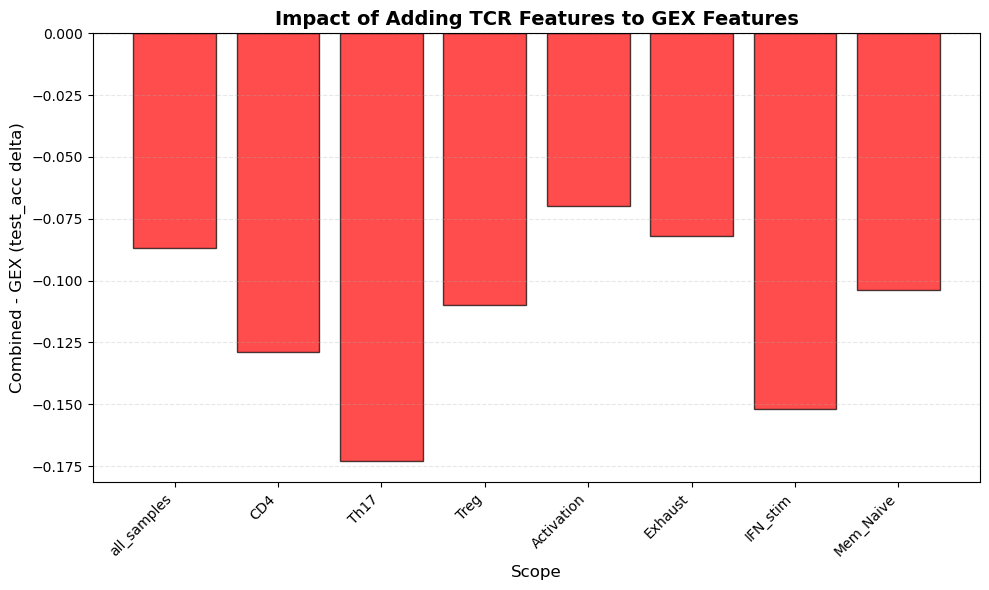


Positive values indicate improvement when adding TCR features
Negative values indicate degradation when adding TCR features


In [35]:
# Plot combined_minus_gex
if 'comparison_df' in locals() and not comparison_df.empty:
    plt.figure(figsize=(10, 6))
    combined_minus_gex = comparison_df['combined_minus_gex'].values
    scopes = comparison_df.index.values
    
    colors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in combined_minus_gex]
    bars = plt.bar(range(len(scopes)), combined_minus_gex, color=colors, alpha=0.7, edgecolor='black')
    
    plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    plt.xlabel('Scope', fontsize=12)
    plt.ylabel('Combined - GEX (test_acc delta)', fontsize=12)
    plt.title('Impact of Adding TCR Features to GEX Features', fontsize=14, fontweight='bold')
    plt.xticks(range(len(scopes)), scopes, rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print(f"\nPositive values indicate improvement when adding TCR features")
    print(f"Negative values indicate degradation when adding TCR features")


In [36]:
# Placeholder cell intentionally left blank; preprocessing is handled upstream.
comparison_df.to_csv(f'{file_name}_allTCR_{all_tcr_features}_comparison_df.csv', index=False)
